<a href="https://colab.research.google.com/github/pikey-msc/AprendizMaquina/blob/main/2026-2/ArbolesDecisionyReg_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Carga de información GITHUB

In [1]:
try:
    !rm -rf AprendizMaquina
except:
    print("No existe la ruta aún")



!git clone 'https://github.com/pikey-msc/AprendizMaquina'


Cloning into 'AprendizMaquina'...
remote: Enumerating objects: 633, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (92/92), done.
^C


#Carga de librerías

In [2]:
#Cargar módulo de R en Python
# A bit of imports
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load in the r magic
%reload_ext rpy2.ipython
%config IPCompleter.greedy=True
%config InlineBackend.figure_format = 'retina'

In [ ]:
%%R
#install.packages("dplyr")
library(dplyr) # "Libreria utilizada para manejar datos"
library(rpart)
install.packages("rpart.plot")
library(rpart.plot)
install.packages("caret")
library(caret)
install.packages("e1071")
library(e1071)
install.packages("ModelMetrics")
library(ModelMetrics)
install.packages("party")
library(party)
# install.packages("boot")
# library(boot)
# install.packages("ipred")
# library(ipred)
# install.packages("randomForest")
# library(randomForest)
# library(ggplot2)
# install.packages("ISLR")
# library(ISLR)



#Árboles de decisión

**Algoritmos**\
Existen diversos algoritmos para solucionar el problema anterior, cada uno utiliza metodologías distintas para particionar los datos así como para definir el criterio de paro del algorimo.
* ID3
* C4.5

**Elementos**\
Un árbol de decisión está formado por un conjunto de nodos de decisión (interiores) y de nodos-respuesta (hojas):
* Un nodo de decisión está asociado a uno de los atributos y tiene 2 o más ramas que salen de él, cada una de ellas representando los posibles valores que puede tomar el atributo asociado. De alguna forma, un nodo de decisión es como una pregunta que se le hace al ejemplo analizado, y dependiendo de la respuesta que de, el flujo tomará una de las ramas salientes.
* Un nodo-respuesta está asociado a la clasificación que se quiere proporcionar, y nos devuelve la decisión del árbol con respecto al ejemplo de entrada.

**ID3**\
El ID3 construye un árbol de decisión de arriba a abajo, de forma directa, sin hacer uso de backtracking, y basándose únicamente en los ejemplos iniciales proporcionados. Para ello, usa el concepto de Ganancia de Información para seleccionar el atributo más útil en cada paso.\
En cierta forma, sigue un método voraz para decidir la pregunta que mayor ganancia da en cada paso, es decir, aquella que me permite separar mejor los ejemplos entre sí respecto a la clasificación final.

**Informacion**\
La medida que se utiliza se llama entropía y se utiliza para clasificar los elementos procurando:
* Muestra completamente homogénea (es decir, en la que todos se clasifican igual).En este caso, fijaremos la incertidumbre (entropía) a 0
* Muestra igualmente distribuida, es decir, que tiene el mismo número de ejemplos.En este caso, fijaremos la incertidumbre (entropía) a 1

Para medir la incertidumbre de un sistema. Shannon llega a la conclusión de que la mejor función matemática que mide este grado de incertidumbre es la siguiente:

$$\textrm{Information Gain}=IG=\sum_{i=1}^c -p_ilog_2(p_i)$$

donde $S$ es el conjunto de muestras (el sistema analizado), $C$ es el número de diferentes clasificaciones que usamos, y cada $p_i$ es la proporción de ejemplos que hay de la clasificación $i$ en la muestra.

**Ejemplo teórico**\
El algoritmo ID3 se ejecuta recursivamente en nodos que no sean de respuesta (hojas) hasta llegar al caso de entropía nula.

<div class="figure">
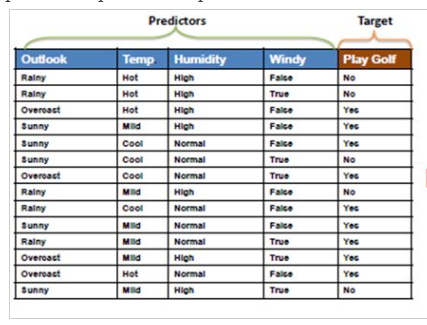

</div>


Paso 1. Antes de realizar ninguna división por atributos, la entropía del sistema es:
<div class="figure">
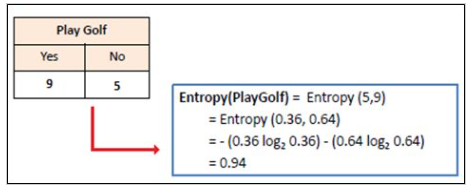

</div>


In [ ]:
%%R
EG=-5/(9+5)*log(5/(9+5),2)-9/(9+5)*log(9/(9+5),2)
EG

Paso 2. Calcula la ganancia que obtendríamos si hicieramos una división usando el primer atributo (Outlook):
<div class="figure">
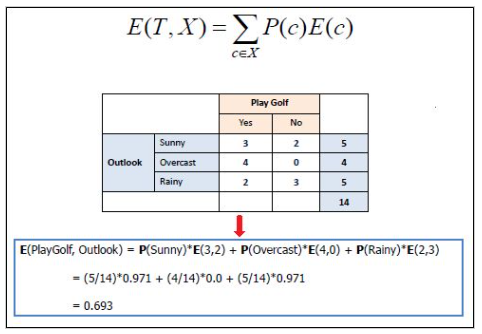

</div>


In [ ]:
%%R
print("Outlook")
print(((-3/(5)*log(3/5,2)-2/(5)*log(2/5,2))*5/14)*2)
print(EG-((-3/(5)*log(3/5,2)-2/(5)*log(2/5,2))*5/14)*2)

print("Temp")
print(EG-((-2/(4)*log(2/4,2)-2/(4)*log(2/4,2))*4/14 + (-4/(6)*log(4/6,2)-2/(6)*log(2/6,2))*6/14 + (-3/(4)*log(3/4,2)-1/(4)*log(1/4,2))*4/14))


Paso 3. Se repite con cada uno de los atributos que tienen los ejemplos:


Paso 4. Se queda con el atributo que proporciona mayor ganancia (en este caso, Outlook), con lo que tenemos construido el primer paso del árbol de decisión, identificando el primer nodo de decisión:
<div class="figure">
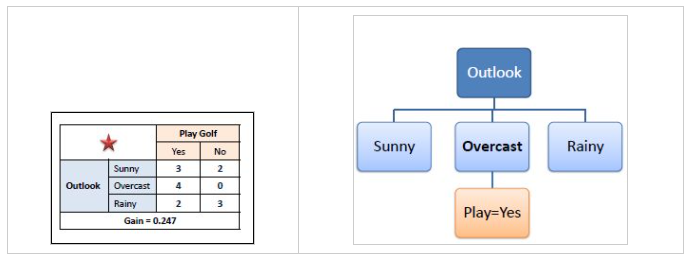

</div>


Paso 5. A continuación nos situamos en cada uno de los subconjuntos de ejemplos que define cada valor del atributo seleccionado y repetimos el proceso, construyendo poco a poco el árbol completo de decisión. Un nodo que tenga entropía nula se convierte en un nodo respuesta, ya que representa una muestra homogénea en el que la clasificación final es la misma para todos los ejemplos que contiene:

Uno de los aspectos más interesantes que nos ofrecen los árboles de decisión como máquinas de predicción es que nos permiten explicar porqué un determinado ejemplo se clasifica de una cierta forma, y podemos extraer un procedimiento que se implementa fácilmente en cualquier sistema haciendo uso de reglas condicionales.
<div class="figure">
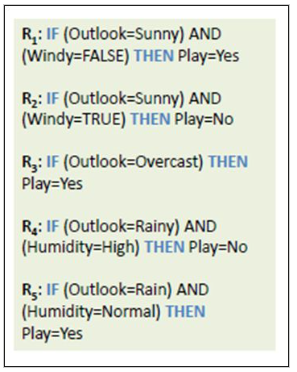

</div>


**Ventajas**
* Son fáciles de entender, interpretar y explicar
* No requieren de mucho trabajo previo en preparar la base de datos de entrenamiento
* Funcionan con datos numéricos y categóricos
* Trabajan con datos no lineales
* Se pueden hacer pruebas estadísticas sobre los resultados, lo cual da mayor confianza al modelo
* Es robusto, funciona incluso si los datos no cumplen con los supuestos
* Es escalable a bases de datos grandes

**Desventajas y limitaciones**
* Alcanzar un óptimo global es un problema, por lo tanto se utilizan heurísticas para encontrar la solución al problema de optimización
* Pequeños cambios en los datos puede resultar en cambios radicales en la segmentación del arbol
* Alta varianza
* El tamaño y complejidad del árbol puede ser muy alto

###Ejemplo. Arbol decision datos IRIS
**Separación en conjunto de entrenamiendo y prueba**
Al igual que en la clase anterior separemos la base de datos en el conjunto de entrenamiento y prueba.

In [ ]:
%%R
data(iris)
print(head(iris))
# Muestra del 80% del total

smp_size <- floor(0.80 * nrow(iris))

# fijar la semilla para que la muestra pueda ser reproducible
# 42 es la respuesta al sentido de la vida, el universo y todo lo demás

set.seed(42)

train_ind <- sample(seq_len(nrow(iris)), size = smp_size)

train <- iris[train_ind, ]
test <- iris[-train_ind, ]
print("tamaño de conjunto de entrenamiento:")
print(nrow(train))
print("tamaño de conjunto de prueba:")
print(nrow(test))

Calcular árbol de decisión

In [ ]:
%%R
part_tree <- rpart(Species ~ .,  data = train, method = "class",
                   minsplit = 5)

summary(part_tree)

Visualizar el árbol

In [ ]:
%%R
rpart.plot(part_tree)

Importancia de cada parámetro

In [ ]:
%%R
part_tree$variable.importance

#### Ejercicio probar en el conjunto de validación

#### Ejercicio Datos IRIS Python

### Ejercicio de Crédito Banco Alemán

In [ ]:
%%R
credit <- read.table("AprendizMaquina/2023-1/Regresion/Datos/credit.txt")

credit=mutate(credit,V21=as.factor(V21))

cred_nam=c("Status of existing checking account","Duration in month","Credit history","Purpose","Credit amount","Present employment since","Installment rate in percentage of disposable income","Personal status and sex","Other debtors / guarantors","Present residence since","Property","A124 : unknown / no property","Age in years","Other installment plans","Housing","Number of existing credits at this bank","Job","Number of people being liable to provide maintenance for","Telephone","foreign worker", "V21")

names(credit)=cred_nam

names(credit)<-make.names(names(credit))

print(summary(credit))
# Define el numero total de renglones de los datos

n <- nrow(credit)

## Define el número de renglones para el conjunto de entrenamiento (80% de la base de datos)

n_train <- round(n * .80)

## Crea un vector de indices que sea el 80% de la muestra aleatoria

set.seed(2^25)

train_indices <- sample(seq_len(n), size = n_train)

# Obten el conjunto de indices para los datos de entrenamiento

credit_train <- credit[train_indices,]#
print("Tamaño datos entrenamiento:")
print(nrow(credit_train))
# Excluye los indices de entrenamiento para crear el conjunto de prueba

 credit_test <- credit[-train_indices, ]
print("Tamaño datos prueba:")
print(nrow(credit_test))
# Utiliza el data frame de credit_train para con los datos de entrenamiento crear un arbol de decision



In [ ]:
%%R
summary(as.factor(credit$V21))
creditb=credit[credit$V21==1,]
creditm=credit[credit$V21==2,]

#Selección de muestra de entrenamiento de buenos (200)
tb <- sample(1:700,200)
credit_trainb <- creditb[tb,]
credit_testb <- creditb[-tb,]

#Selección de muestra de entrenamiento de malos (200)
tm <- sample(1:300,200)
credit_trainm <- creditm[tm,]
credit_testm <- creditm[-tm,]

credit_train=rbind(credit_trainb,credit_trainm)
credit_test=rbind(credit_testb,credit_testm)

print(nrow(credit_train))
print(nrow(credit_test))



Calcular el modelo

In [ ]:
%%R
# Define el modelo de entrenamiento

credit_model <- rpart(formula = as.factor(V21)~.,
                      data = credit_train,
                      method = "class",parms = list(split = "information") )
rpart.plot(credit_model)
# Observa las salidas del modelo

print(credit_model)

# Genera la clase de predicción para los datos de "credit_test"

# Utiliza la matriz de confusión para los datos prueba

# Genera el modelo de predicción
 class_prediction <- predict(object =credit_model,
                        newdata = credit_test,
                        type = "class")

# Calcula la matriz de confusión para el conjunto de datos prueba
 confusionMatrix(as.factor(credit_test$V21), class_prediction)


In [ ]:
%%R
rpart.plot(credit_model)

In [ ]:
%%R
 class_prediction <- predict(object =credit_model,
                        newdata = credit_test,
                        type = "class")
print(summary(as.factor(credit_test$V21)))
print(head(class_prediction))
# Calcula la matriz de confusión para el conjunto de datos prueba
 table(credit_test$V21, as.factor(class_prediction))

#### Ejercicio Crédito Python

##Método de segmentación Gini
La idea de la segmentación del arbol es crear segmentaciones puras
<div class="figure">
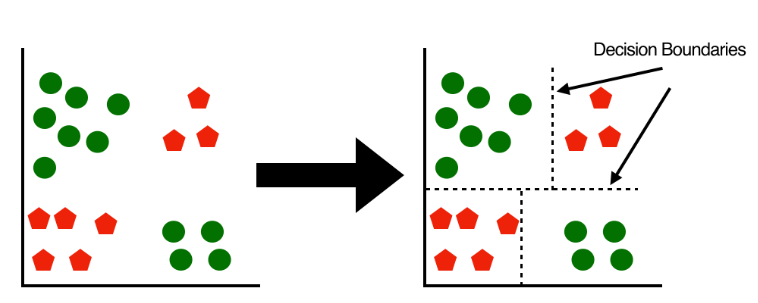

</div>


Sin embargo, esto no es posible, por lo que los algoritmos de segmentación del arbol crearan regiones lo mas puras posible.\
La segmentación de Gini busca obtener grupos mas homogeneos


Por tanto, es una escala que permite medir que tan puro es el modelo.
<div class="figure">
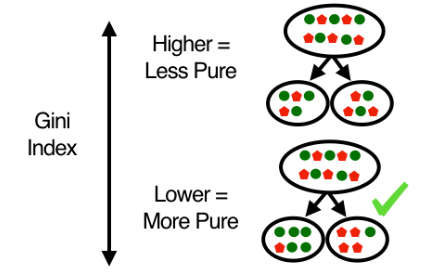

</div>


Entre mas puro es el modelo, menor sera el indice de Gini y viceversa.\
Ejemplo de datos de crédito con modelo de Gini.
Compara dos modelos que utilizan dos criterios diferentes (gini o information) y utiliza la validacion para escoger el mejor modelo de este grupo.

1. Modelo 1 con la condición split = gini

2. Modelo 2 con la condicion split = information

3. Genera predicciones sobre el conjunto de validaciones de ambos modelos

4. La clasificación del error “ce()” es la fracción incorrectamente clasificada de instancias. Computa y compara los datos prueba de ambos modelos.

In [ ]:
%%R
 # Modelo Gini
 credit_model1 <- rpart(formula = V21 ~ .,
                        data = credit_train,
                        method = "class",
                        parms = list(split = "gini"))
 summary(credit_model1)
 rpart.plot(credit_model1)
 # Modelo information
 credit_model2 <- rpart(formula = V21 ~ .,
                        data = credit_train,
                        method = "class",
                        parms = list(split = "information"))
 rpart.plot(credit_model2)

 # Genera predicciones a partir del modelo de Gini
 pred1 <- predict(object =credit_model1,
                  newdata = credit_test,
                  type = "class")

 # Genera predicciones a partir del modelo de Information
 pred2 <- predict(object =credit_model2,
                  newdata = credit_test,
                  type = "class")

 # Comparacion de modelo clasificacion


In [ ]:
%%R
rpart.plot(credit_model1)

In [ ]:
%%R
 print(confusionMatrix(as.factor(credit_test$V21), as.factor(pred1)))


 print(confusionMatrix(as.factor(credit_test$V21),as.factor(pred2)))

print( ce(actual = credit_test$V21,
      predicted = pred1))
 print(ce(actual = credit_test$V21,
      predicted = pred2))


#### Ejercicio Crédito Gini Python

## Árboles de Regresión
Los árboles de regresión sirven para cuando la salida no es una variable categórica, es decir, es numérica.
Las metricas de regresion mas comunes para evaluar el modelo son:
$MAE$ y $RMSE$


Estas metricas miden la distancia que existe entre el valor proyectado por el modelo versus el valor real.En ambos casos, mientras menor sea el valor de estas metricas, mejor sera el modelo de predicción.

### Ejercicio Estudiantes
Datos del Comportamiento de los estudiantes
El objetivo de estos datos es predecir la calificación del examen final de los estudiantes de matemáticas en base a las siguientes variables: sexo, edad, dirección, tiempo de estudio, materia optativa, educación de la familia, pago de extra clase e inasistencias. Para este caso la variable respuesta es la calificación final (numerica de 0 a 20). La información puede consultarse en:
https://archive.ics.uci.edu/ml/datasets/student+performance
En este ejercicio, se dividen los datos en: Entrenamiento (training), Validación (validation) y Prueba (test).
Se Introduce una nueva particion (validation) que sera utilizada para seleccionar el “mejor modelo” dentro de un conjunto de modelos.\
Durante el curso hemos demostrado diversas formas de separar la información en dos conjuntos mediante la función muestra (sample).\
Para este ejercicio se utilizara nuevamente la función sample, para separar la información en tres conjuntos.
Sin embargo, en lugar de muestrear los indices, se utilizara la función `sample()` para asignar a cada renglon dentro de alguno de los conjuntos utilizando una distribución de probabilidad.

Dividir la base en train, valid y test
Abrir los datos y segmentar la base de datos en: train, valid y test

In [ ]:
%%R
# Verificar que la tabla tiene 33 variables
grade_all <- read.csv("AprendizMaquina/2023-1/Regresion/Datos/student-mat.csv", header = TRUE,sep=";")


# Seleccionar solo 8 variables
grade <- select(grade_all,G1,age, address, studytime, schoolsup,famsup,paid, absences)

# Segmentar de forma aleatoria los renglones en 3 conjuntos: train (70%), valid (15%) y test (15%)
set.seed(1)
assignment <- sample(1:3, size = nrow(grade), prob = c(.70,.15,.15), replace = TRUE)

# Crear las bases de datos a partir de la segmentación anterior

grade_train <- grade[assignment == 1, ]    # subset the grade data frame to training indices only
grade_valid <- grade[assignment == 2, ]  # subset the grade data frame to validation indices only
grade_test <- grade[assignment == 3, ]   # subset the grade data frame to test indices only
print("n entrenamiento")
print(nrow(grade_train))
print("n prueba")
print(nrow(grade_valid))
print("n validación")
print(nrow(grade_test))

Se utilizara la tabla “grade_train”" para ajustar un árbol de regresión utilizando la paquetería `rpart()` y visualizarla con `rpart.plot()`. El arbol de regresion se vera identico a un arbol de clasificación con la excepcion de que tendra valores numericos en los nodos en lugar de clases de predicción.\
Para ajustar un arbol de decision es importante utilizar el metodo `class`, sin embargo para un arbol de regresión se debe utilizar el metodo ``anova``.

In [ ]:
%%R
# Modelo de entrenamiento
grade_model <- rpart(formula = G1 ~ .,
                     data = grade_train,
                     method = "anova")

# Ver la salida del modelo
print(grade_model)
# Grafica del arbol de decision
rpart.plot(x = grade_model, yesno = 2, type = 0, extra = 0)

Evaluar el modelo de árbol de regresión
* Paso.1 Predecir la calificación final de todos los estudiantes para el conjunto test.
* Paso 2. Evaluar el modelo con la metrica RMSE (Root Mean Squared Error). Esta métrica mide la distancia entre las valores proyectados con respecto a los valores reales.

In [ ]:
%%R
pred <- predict(object = grade_model,   # model objecto
                newdata = grade_test)  # datos test

# Calulo del RMSE
rmse(actual = grade_test[,1],
     predicted = pred)

#### Ejercicio Estudiantes Python

### Hiperparámetros del árbol de regresión
Los hiperparametros de un arbol de regresión se utiliza para ajustar mejor el arbol de decision.
En general se pueden hacer 3 tipos de ajuste:
> ``minslip`` = Establece el número minimo de datos requerido para crear la segmentación del nodo del arbol. Por default n = 20

> ``cp``= Parametro de complejidad que va de cero a uno. Entre mas pequeño sea este valor mas complejo sera el arbol(se incrementa el número de segmentos)

> ``maxdepth`` = Profundidad del arbol define el número del nodos del arbol. Por default $n = 30$

La librería ``rpart()`` calcula 10 escenarios de arbol variando el cp los cuales pueden ser analizados con la función ``plotcp()``, para este caso se elegira el valor cp cuyo xerror sea el mas pequeño.
Una vez definido el valor de cp se puede tunear el modelo con la función ``prune()``, el cual regresa el modelo optimizado.

**Tuneando el modelo**\
Utiliza la función ``prune`` y encuentra el mejor valor “CP” (Complexity Parameter)

In [ ]:
%%R
# Gráfica de la tabla CP
plotcp(grade_model)
# Imprimir la tabla CP
print(grade_model$cptable)

Obtener el valor cp obtimo a partir de varios escenarios (cross-validated error)


In [ ]:
%%R
opt_index <- which.min(grade_model$cptable[, "xerror"])
cp_opt <- grade_model$cptable[opt_index, "CP"]

# Tunear el modelo con el valor cp optimo
grade_model_opt <- prune(tree = grade_model,
                         cp = cp_opt)

# Grafica del modelo optimo
rpart.plot(x = grade_model_opt, yesno = 2, type = 0, extra = 0)

**Selección del Modelo**\
Modelar diferentes modelos con distintas combinaciones en sus hiperparametros es el objetivo durante la selección del modelo.\
Para elegir el mejor se debera elegir la metrica de medición que mejor aplique a cada caso particular), pr ejemplo: AUC y/o RMSE.\
Sin embargo, la elección de hiperparametros para efectuar la combinación solo se puede hacer de forma manual mediante la gunción expand.grid().

In [ ]:
%%R
# Establece una lista de posibles valores para minsplit y maxdepth
minsplit <- seq(1, 4, 1)
maxdepth <- seq(1, 6, 1)

# Crea u data frame que contenga todas las combinaciones
hyper_grid <- expand.grid(minsplit = minsplit, maxdepth = maxdepth)

# Revisar la combinación de distintos modelos
print(head(hyper_grid))
# Imprimir el número de combinaciones o modelos
nrow(hyper_grid)

En este apartado contruiremos un loop para entrenar los modelos u guardar los resultados en una lista llamada “grade_models”

In [ ]:
%%R
# Definir el numero de modelos

num_models <- nrow(hyper_grid)

# Crear una lista vacia para guardar los modelos

grade_models <- list()

# Escribir un loop sobre los renglones de los modelos
for (i in 1:num_models) {

    # Obtener los valores deminsplit, maxdepth  para cada renglon i
    minsplit <- hyper_grid$minsplit[i]
    maxdepth <- hyper_grid$maxdepth[i]

    # Entrena el modelo y guardarlo en la lista grade_models
    grade_models[[i]] <- rpart(formula = G1 ~ .,
                               data = grade_train,
                               method = "anova",
                               minsplit = minsplit,
                               maxdepth = maxdepth)
}

En esta sección se utiliza la tabla de validación (validation) para evaluar el performance de un conjunto de modelos con el fin de obtener el mejor modelo del grupo.
Todos los modelos del grupo con evaluados con la misma base de validación y el que tenga mejor performance sera considerado como ganador.\
Una vez que se obtiene el mejor modelo, una estimacion final del performance es computado sobre la base de prueba (test)\
La tabla de datos de prueba (test) solo debe utilizarse para estimar el performance y no en la selección del modelo.

In [ ]:
%%R
# Numero potencial de modelos
num_models <- length(grade_models)

# Crea un vector vacio para guardar los resultados del RMSE
rmse_values <- c()

# Escribe un loop sobre el modelo para guardar los valores RMSE
for (i in 1:num_models) {

    # Actualiza el i - esimo modelo de la lista
    model <- grade_models[[i]]

    # Genera predicciones
    pred <- predict(object = model,
                    newdata = grade_valid)

    # Calcula el valor de RMSE
    rmse_values[i] <- rmse(actual = grade_valid$G1,
                           predicted = pred)
}

# Identifica el modelo con el menor RMSE
best_model <- grade_models[[which.min(rmse_values)]]

# Imprime los parametros del mejor modelo
best_model$control

Calcula el RMSE de la base de datos prueba (train)

In [ ]:
%%R
# Calcula el RMSE de la base de datos prueba (train)
pred <- predict(object = best_model,
                newdata = grade_test)
rmse(actual = grade_test$G1,
     predicted = pred)

#### Ejercicio Hiperpámetros Python